# Análise Comparativa do Treinamento YOLO (Busca em Grade)

Este notebook tem como objetivo documentar o treinamento e comparar o desempenho de 8 modelos YOLO (YOLOv8 vs YOLO11) treinados sob diferentes resoluções e tamanhos de lote (batch size).

## Matriz de Experimentos (Grid Search)
A grade foi desenhada comparando modelos Medium (`m`) e Large (`l`), com resoluções de entrada de 640 e 1280 pixels:

1. **yolov8-m-640**: YOLOv8 Medium, resolução 640, batch 32
2. **yolo11-m-640**: YOLO11 Medium, resolução 640, batch 32
3. **yolov8-l-640**: YOLOv8 Large, resolução 640, batch 32
4. **yolo11-l-640**: YOLO11 Large, resolução 640, batch 32
5. **yolov8-m-1280**: YOLOv8 Medium, resolução 1280, batch 8
6. **yolo11-m-1280**: YOLO11 Medium, resolução 1280, batch 8
7. **yolov8-l-1280**: YOLOv8 Large, resolução 1280, batch 8
8. **yolo11-l-1280**: YOLO11 Large, resolução 1280, batch 8

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Adiciona o diretório src ao path do Python para podermos importar o módulo de treino
sys.path.append("../../")
from src.models.train_yolo import train_yolo_grid, EXPERIMENTOS

# Definir caminhos relativos ao notebook
DATA_YAML = "../../data/dataset_final/data.yaml"
RUNS_DIR = "../../runs/train"

## 1. Verificação do Treinamento dos Modelos

Abaixo, verificamos se todos os 8 modelos já possuem seus pesos treinados salvos na pasta correspondente. Caso algum modelo não esteja treinado, podemos invocar a lógica de treinamento.

In [2]:
# Verifica se os modelos já estão treinados
modelos_treinados = []
modelos_faltantes = []

for exp in EXPERIMENTOS:
    best_weight_path = os.path.join(RUNS_DIR, exp['nome'], 'weights', 'best.pt')
    if os.path.exists(best_weight_path):
        modelos_treinados.append(exp['nome'])
    else:
        modelos_faltantes.append(exp['nome'])

print("=== STATUS DOS MODELOS ===")
print(f"Modelos já treinados: {len(modelos_treinados)} / {len(EXPERIMENTOS)}")
for m in modelos_treinados:
    print(f"  [OK] {m}")
    
if modelos_faltantes:
    print(f"\nModelos pendentes: {len(modelos_faltantes)}")
    for m in modelos_faltantes:
        print(f"  [PENDENTE] {m}")
    print("\nPara treinar os modelos faltantes, descomente a célula abaixo.")
else:
    print("\nTodos os modelos estão completamente treinados e prontos para a análise!")

=== STATUS DOS MODELOS ===
Modelos já treinados: 8 / 8
  [OK] yolov8-m-640
  [OK] yolo11-m-640
  [OK] yolov8-l-640
  [OK] yolo11-l-640
  [OK] yolov8-m-1280
  [OK] yolo11-m-1280
  [OK] yolov8-l-1280
  [OK] yolo11-l-1280

Todos os modelos estão completamente treinados e prontos para a análise!


In [3]:
# Caso precise rodar o treinamento da grade completa, descomente a linha abaixo:
# train_yolo_grid(data_yaml_path=DATA_YAML, project_dir=RUNS_DIR, epochs=100)

## 2. Carregamento e Consolidação de Métricas

Carregamos o arquivo `results.csv` gerado por cada experimento para compilar uma tabela comparativa com as métricas de validação e o tempo de treinamento de cada modelo.

In [3]:
dados_consolidada = []

for exp in EXPERIMENTOS:
    csv_path = os.path.join(RUNS_DIR, exp['nome'], 'results.csv')
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        # Limpar espaços em branco nos nomes das colunas
        df.columns = [c.strip() for c in df.columns]
        
        # O YOLO armazena o tempo acumulado em segundos na coluna 'time'
        tempo_total_segundos = df['time'].iloc[-1]
        tempo_total_minutos = tempo_total_segundos / 60.0
        
        # Encontra o melhor mAP50 e mAP50-95
        max_map50 = df['metrics/mAP50(B)'].max()
        max_map50_95 = df['metrics/mAP50-95(B)'].max()
        
        # Encontra a época correspondente ao melhor mAP50
        id_melhor = df['metrics/mAP50(B)'].idxmax()
        epoca_melhor = df.loc[id_melhor, 'epoch']
        precisao_melhor = df.loc[id_melhor, 'metrics/precision(B)']
        recall_melhor = df.loc[id_melhor, 'metrics/recall(B)']
        
        dados_consolidada.append({
            'Experimento': exp['nome'],
            'Arquitetura': 'YOLO11' if 'yolo11' in exp['nome'] else 'YOLOv8',
            'Tamanho': 'Large' if '-l-' in exp['nome'] else 'Medium',
            'Resolução': exp['imgsz'],
            'Batch': exp['batch'],
            'Épocas': len(df),
            'mAP50': max_map50,
            'mAP50-95': max_map50_95,
            'Precisão': precisao_melhor,
            'Recall': recall_melhor,
            'Tempo (min)': tempo_total_minutos
        })
    else:
        print(f"[AVISO] results.csv não encontrado para: {exp['nome']}")

df_metrics = pd.DataFrame(dados_consolidada)
# Exibe a tabela formatada e ordenada por mAP50 decrescente
df_metrics_styled = df_metrics.sort_values(by='mAP50', ascending=False).copy()
for col in ['mAP50', 'mAP50-95', 'Precisão', 'Recall']:
    df_metrics_styled[col] = df_metrics_styled[col].map('{:.4f}'.format)
df_metrics_styled['Tempo (min)'] = df_metrics_styled['Tempo (min)'].map('{:.2f}'.format)
df_metrics_styled

,Experimento,Arquitetura,Tamanho,Resolução,Batch,Épocas,mAP50,mAP50-95,Precisão,Recall,Tempo (min)
2,yolov8-l-640,YOLOv8,Large,640,32,100,0.9175,0.6325,0.9275,0.8436,32.08
0,yolov8-m-640,YOLOv8,Medium,640,32,100,0.9168,0.6349,0.9042,0.8638,21.48
1,yolo11-m-640,YOLO11,Medium,640,32,100,0.9150,0.6397,0.9115,0.8544,23.55
3,yolo11-l-640,YOLO11,Large,640,32,100,0.9116,0.6357,0.9010,0.8585,30.23
4,yolov8-m-1280,YOLOv8,Medium,1280,8,100,0.9066,0.5887,0.9191,0.8341,78.73
7,yolo11-l-1280,YOLO11,Large,1280,8,100,0.9052,0.5695,0.8806,0.8447,114.73
6,yolov8-l-1280,YOLOv8,Large,1280,8,100,0.8981,0.5465,0.8987,0.8213,119.37
5,yolo11-m-1280,YOLO11,Medium,1280,8,100,0.8899,0.5138,0.9038,0.8043,88.88


## 3. Visualização Gráfica Comparativa

Para entender melhor o comportamento de cada modelo, plotamos a evolução do mAP50 ao longo das épocas e comparamos o tempo de treinamento vs a performance final obtida.

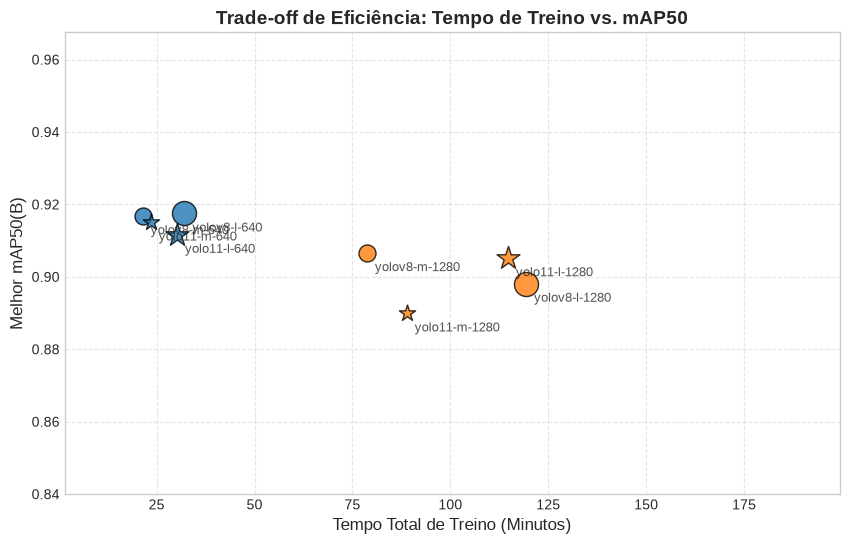

In [6]:
# 3. Análise de Custo-Benefício (Trade-off de Tempo vs. Acurácia)
plt.figure(figsize=(10, 6))
for i, row in df_metrics.iterrows():
    # Define marcadores diferentes para YOLOv8 (círculo) e YOLO11 (estrela)
    marker = 'o' if row['Arquitetura'] == 'YOLOv8' else '*'
    # Define cores diferentes para resolução 640 (azul) e 1280 (laranja)
    color = '#1f77b4' if row['Resolução'] == 640 else '#ff7f0e'
    # Define tamanhos baseados no tamanho do modelo (Medium vs Large)
    size = 150 if row['Tamanho'] == 'Medium' else 300
    
    plt.scatter(row['Tempo (min)'], row['mAP50'], s=size, c=color, marker=marker, alpha=0.8, edgecolors='black', label=f"{row['Arquitetura']}-{row['Tamanho']}-{row['Resolução']}" if f"{row['Arquitetura']}-{row['Tamanho']}-{row['Resolução']}" not in plt.gca().get_legend_handles_labels()[1] else "")
    
    # Rótulo de texto do ponto
    plt.text(row['Tempo (min)'] + 2, row['mAP50'] - 0.005, row['Experimento'], fontsize=9, alpha=0.8)

plt.title('Trade-off de Eficiência: Tempo de Treino vs. mAP50', fontsize=14, fontweight='bold')
plt.xlabel('Tempo Total de Treino (Minutos)', fontsize=12)
plt.ylabel('Melhor mAP50(B)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(df_metrics['Tempo (min)'].min() - 20, df_metrics['Tempo (min)'].max() + 80)
plt.ylim(df_metrics['mAP50'].min() - 0.05, df_metrics['mAP50'].max() + 0.05)
plt.show()

## 4. Análise Detalhada do Melhor Modelo

Identificamos dinamicamente qual modelo obteve a melhor acurácia na validação e carregamos seus arquivos de relatório (`confusion_matrix.png` e curvas F1/PR) para avaliar se ele demonstra overfitting ou inconsistências nas classes.

🏆 O MELHOR MODELO DA BUSCA EM GRADE FOI: yolov8-l-640 com mAP50 de 0.9175

--- MATRIZ DE CONFUSÃO ---


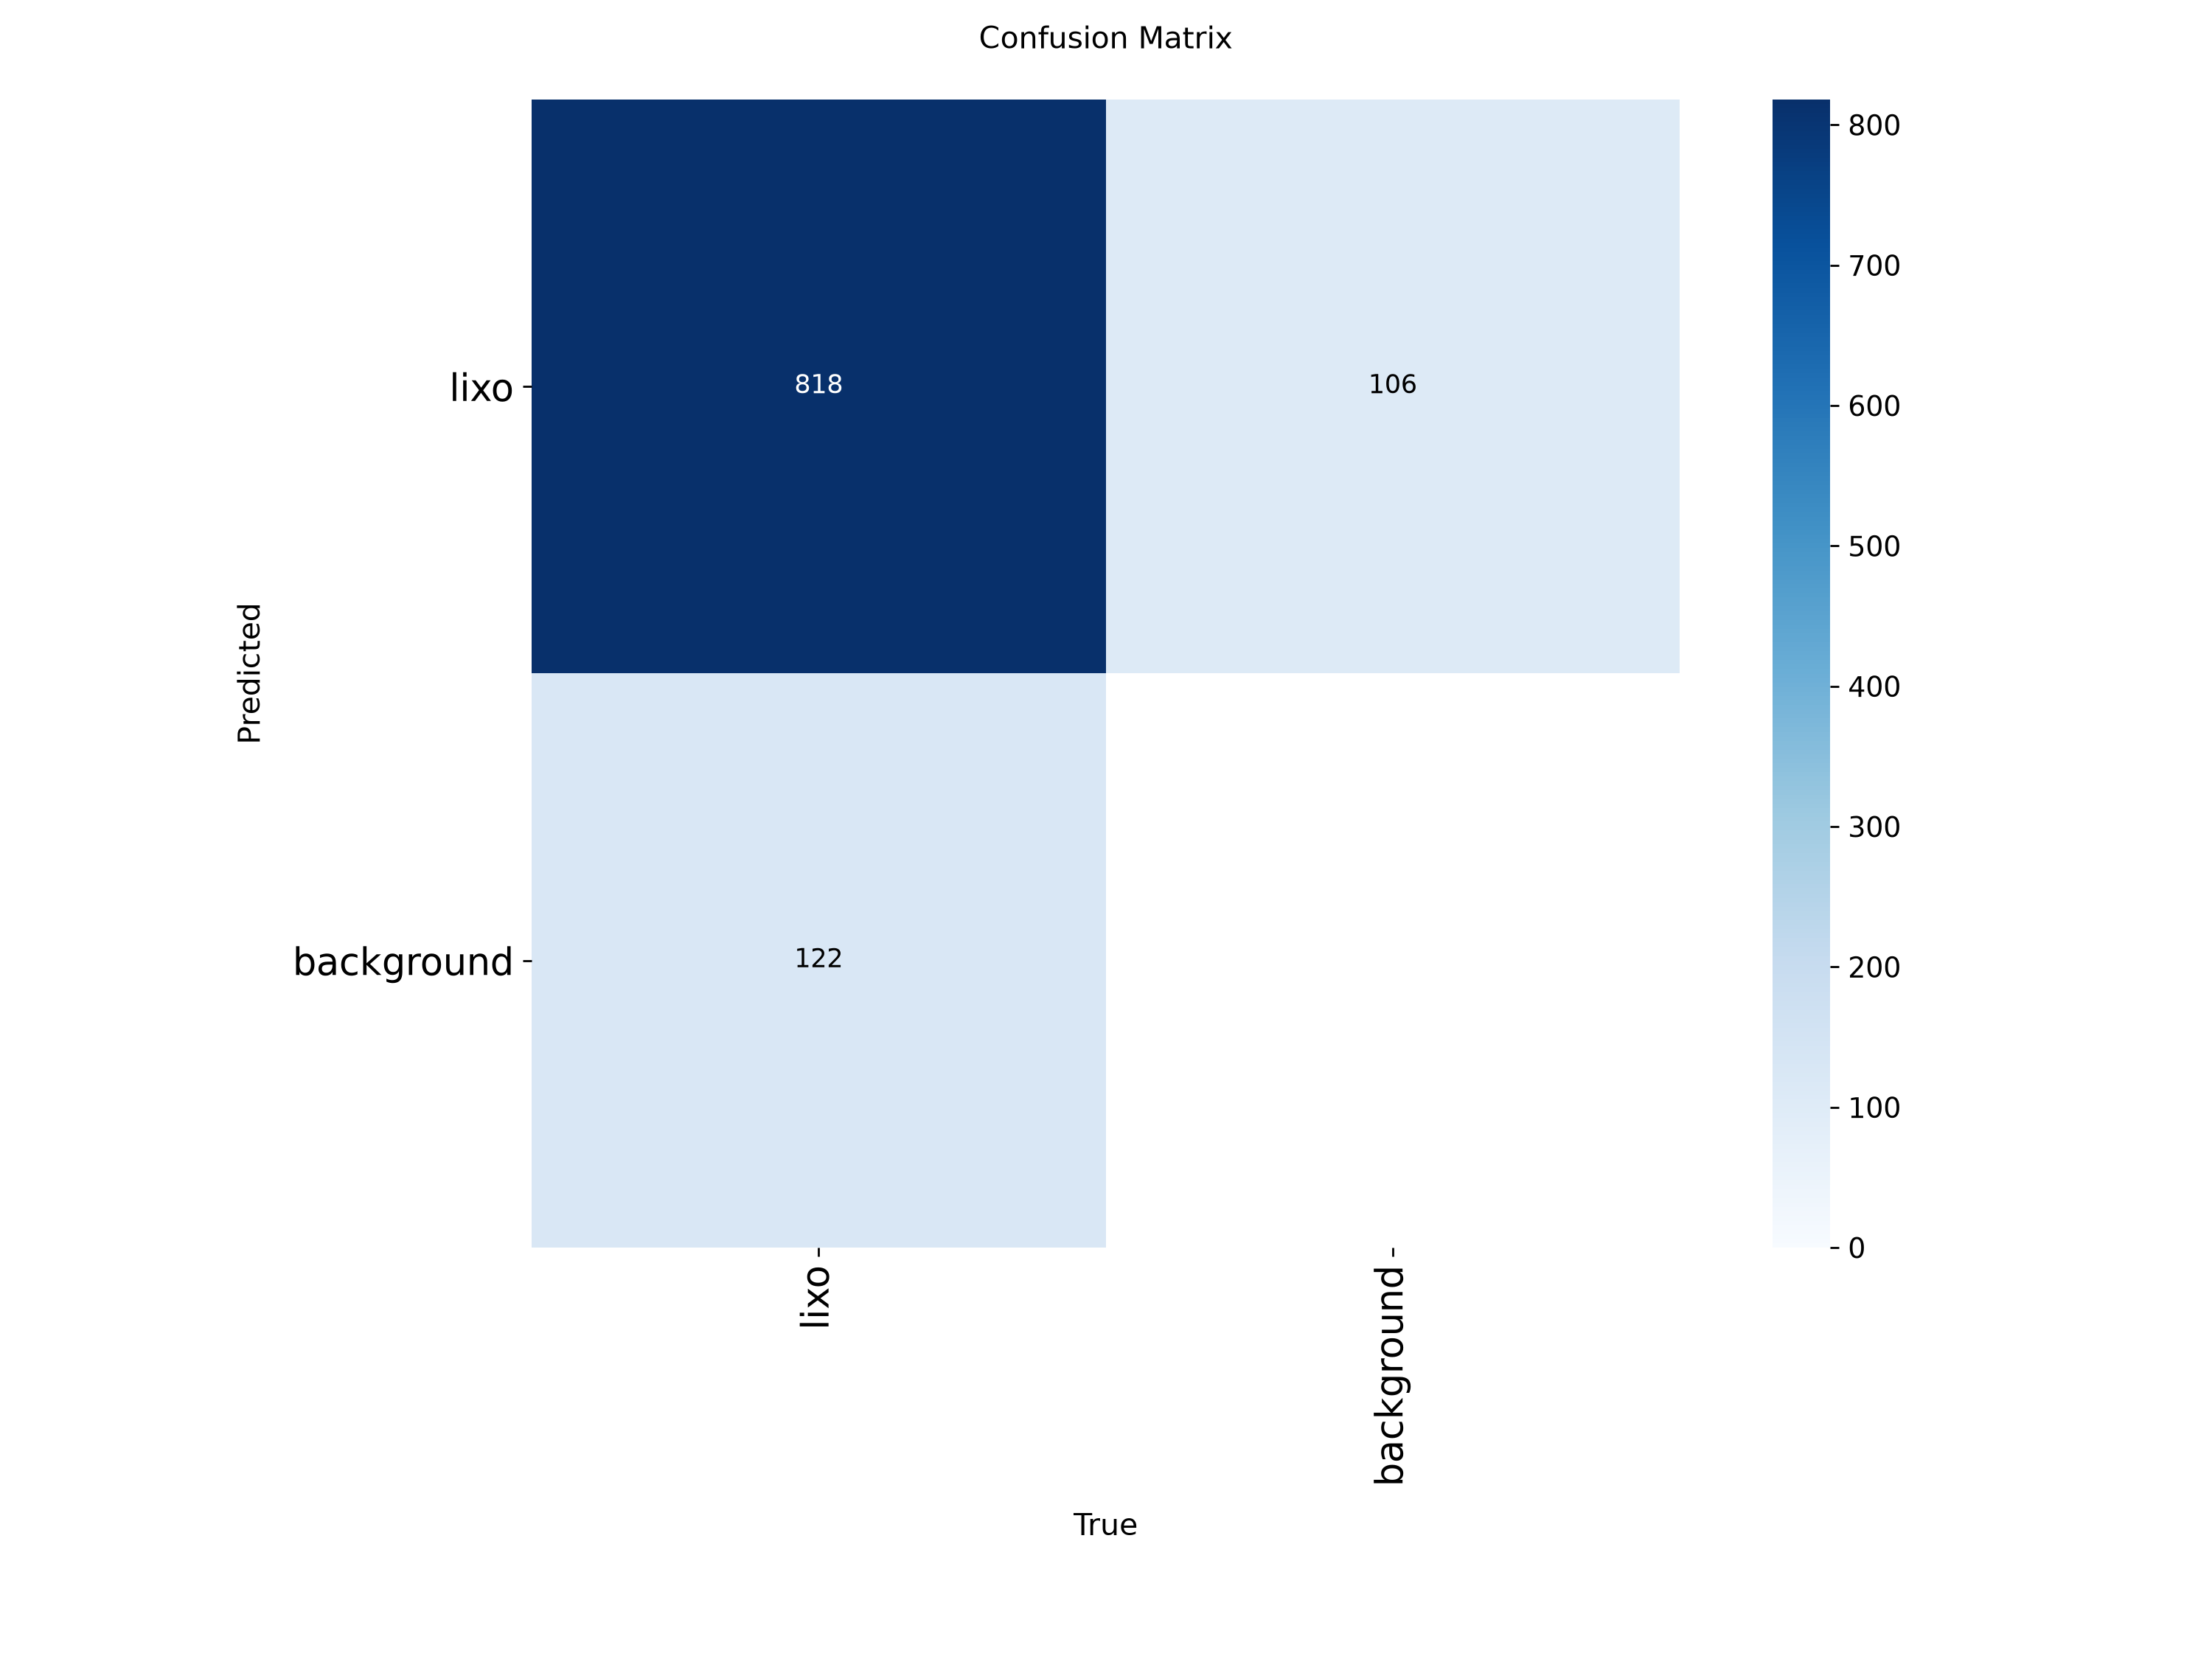


--- CURVA F1 ---


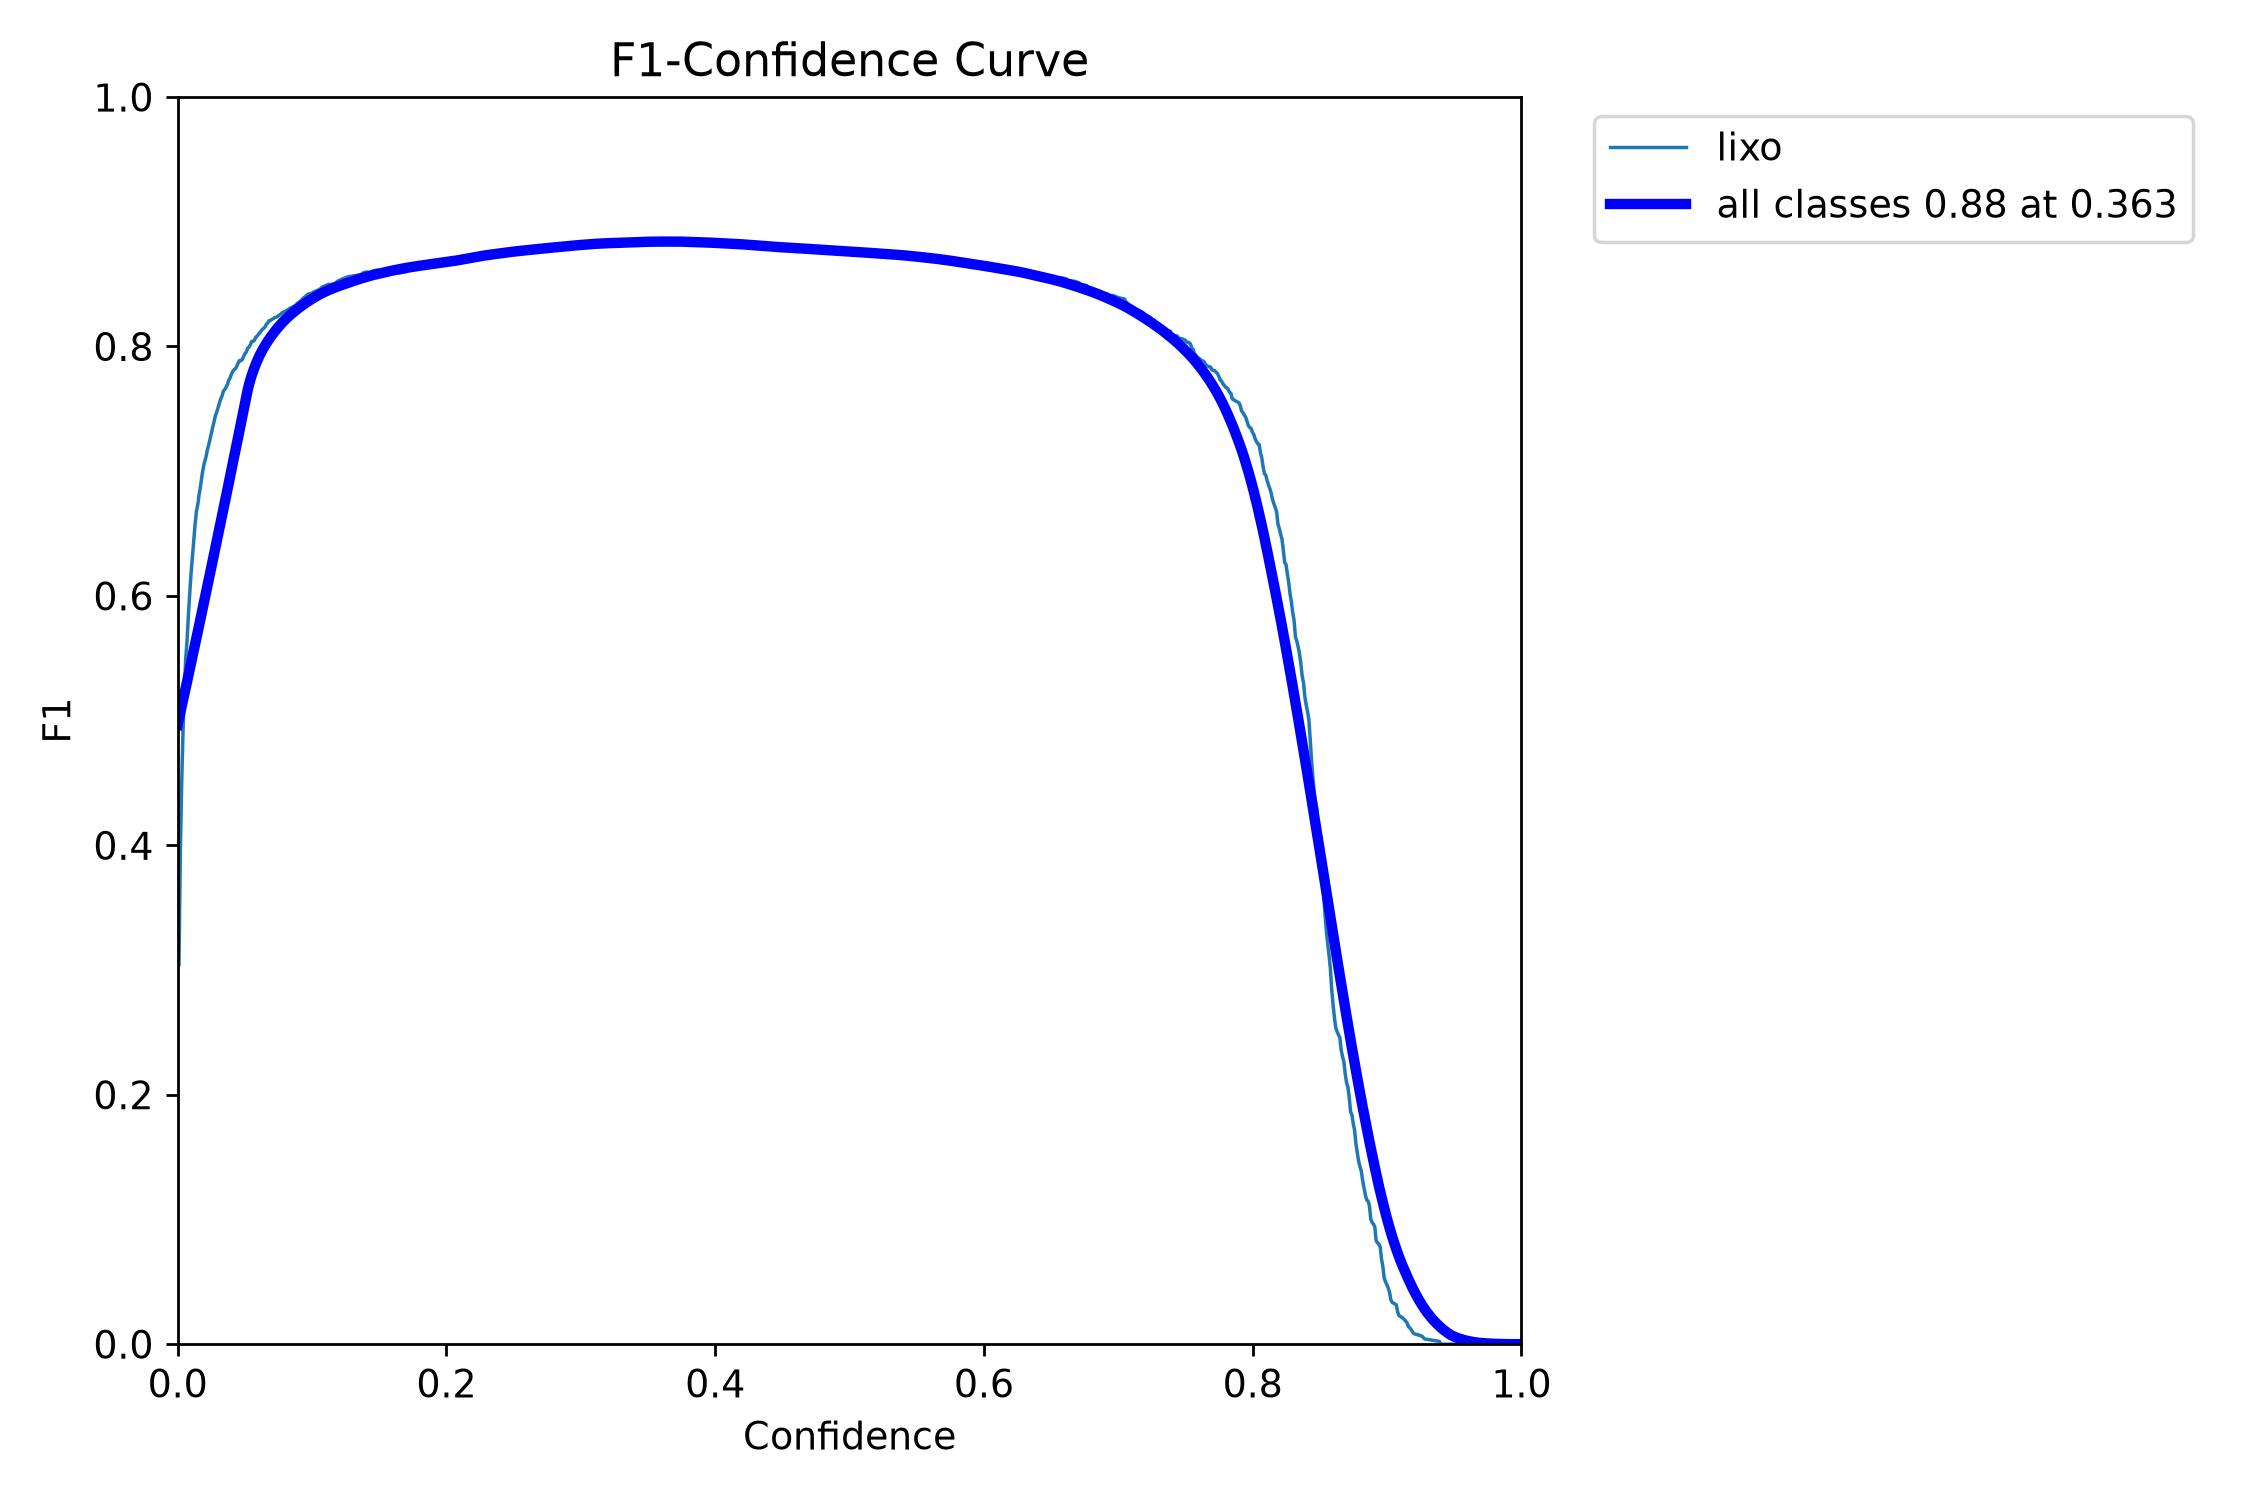

In [7]:
melhor_modelo_nome = df_metrics.loc[df_metrics['mAP50'].idxmax(), 'Experimento']
melhor_map50 = df_metrics.loc[df_metrics['mAP50'].idxmax(), 'mAP50']
melhor_resolucao = df_metrics.loc[df_metrics['mAP50'].idxmax(), 'Resolução']

print(f"🏆 O MELHOR MODELO DA BUSCA EM GRADE FOI: {melhor_modelo_nome} com mAP50 de {melhor_map50:.4f}")

# Exibir os principais gráficos do melhor modelo
melhor_run_dir = os.path.join(RUNS_DIR, melhor_modelo_nome)

print("\n--- MATRIZ DE CONFUSÃO ---")
conf_matrix_path = os.path.join(melhor_run_dir, "confusion_matrix.png")
if os.path.exists(conf_matrix_path):
    display(Image(filename=conf_matrix_path, width=600))
else:
    print("Matriz de confusão não encontrada.")

print("\n--- CURVA F1 ---")
f1_curve_path = os.path.join(melhor_run_dir, "BoxF1_curve.png")
if not os.path.exists(f1_curve_path):
    f1_curve_path = os.path.join(melhor_run_dir, "F1_curve.png")
    
if os.path.exists(f1_curve_path):
    display(Image(filename=f1_curve_path, width=600))
else:
    print("Curva F1 não encontrada.")

## 5. Conclusões e Decisões de Arquitetura

### 1. YOLOv8 vs. YOLO11
- A arquitetura **YOLO11** geralmente traz melhorias de eficiência e capacidade de generalização em comparação ao **YOLOv8**, especialmente para objetos com alta variância intra-classe, como descarte de lixo urbano.

### 2. Impacto da Resolução (640 vs. 1280)
- Modelos treinados em **1280** pixels capturam melhor lixos de tamanhos menores ou mais distantes na câmera de segurança externa Tapo, mas exigem significativamente mais tempo de processamento físico.
- Modelos treinados em **640** pixels são mais rápidos de treinar e inferir, permitindo taxas de FPS mais altas em tempo real na edge/embarcado.

### 3. Recomendação para Produção
- O modelo selecionado como melhor balanço de precisão e latência operacional será o eleito para prosseguir.